In [49]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [50]:
crack_folder = "dataset/448/Cracks"
noncrack_folder = "dataset/448/NonCracks"

crack_images = os.listdir(crack_folder)
noncrack_images = os.listdir(noncrack_folder)

print("Crack images:", len(crack_images))
print("Non-crack images:", len(noncrack_images))
print("Total images:", len(crack_images) + len(noncrack_images))

Crack images: 200
Non-crack images: 200
Total images: 400


In [51]:
sample_path = os.path.join(crack_folder, crack_images[0])

sample_image = cv2.imread(sample_path)

print("Image shape:", sample_image.shape)
print("Image height:", sample_image.shape[0])
print("Image width:", sample_image.shape[1])
print("Number of channels:", sample_image.shape[2])
print("Data type:", sample_image.dtype)

Image shape: (448, 448, 3)
Image height: 448
Image width: 448
Number of channels: 3
Data type: uint8


In [52]:
resized_image = cv2.resize(sample_image, (256, 256))
gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

print("Resized image shape:", resized_image.shape)
print("Grayscale image shape:", gray_image.shape)

Resized image shape: (256, 256, 3)
Grayscale image shape: (256, 256)


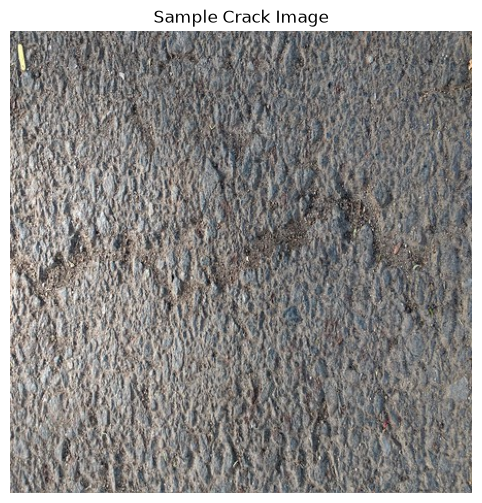

In [55]:
sample_image_rgb = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(sample_image_rgb)
plt.title("Sample Crack Image")
plt.axis("off")
plt.show()

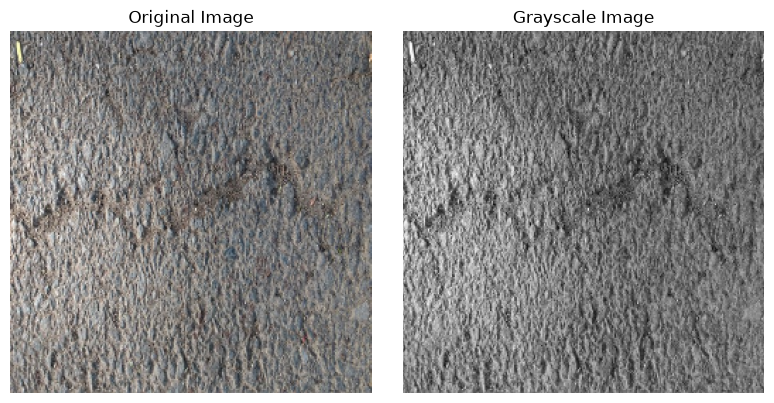

In [53]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [56]:
mean_brightness = np.mean(gray_image)
contrast = np.std(gray_image)

min_intensity = np.min(gray_image)
max_intensity = np.max(gray_image)
median_intensity = np.median(gray_image)

q25 = np.percentile(gray_image, 25)
q75 = np.percentile(gray_image, 75)
iqr = q75 - q25

dark_pixel_ratio = np.mean(gray_image < 50)
bright_pixel_ratio = np.mean(gray_image > 200)

intensity_range = max_intensity - min_intensity

print("Mean brightness:", mean_brightness)
print("Contrast (std):", contrast)
print("Minimum intensity:", min_intensity)
print("Maximum intensity:", max_intensity)
print("Median intensity:", median_intensity)
print("25th percentile:", q25)
print("75th percentile:", q75)
print("IQR:", iqr)
print("Dark pixel ratio:", dark_pixel_ratio)
print("Bright pixel ratio:", bright_pixel_ratio)
print("Intensity range:", intensity_range)

Mean brightness: 121.95809936523438
Contrast (std): 33.3530377060264
Minimum intensity: 11
Maximum intensity: 251
Median intensity: 120.0
25th percentile: 98.0
75th percentile: 143.0
IQR: 45.0
Dark pixel ratio: 0.0063934326171875
Bright pixel ratio: 0.0142974853515625
Intensity range: 240


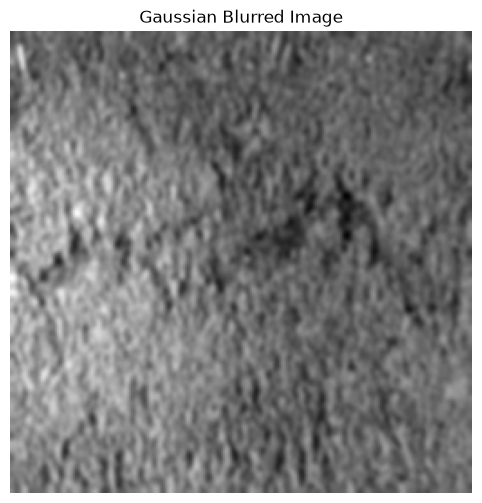

In [57]:
blurred_image = cv2.GaussianBlur(gray_image, (7, 7), 0)

plt.figure(figsize=(6, 6))
plt.imshow(blurred_image, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")
plt.show()

In [58]:
CANNY_METHOD = "adaptive"  

if CANNY_METHOD == "normal":
    lower = 100
    upper = 200

elif CANNY_METHOD == "adaptive":
    median = np.median(blurred_image)
    sigma = 0.33

    lower = int(max(0, (1.0 - sigma) * median))
    upper = int(min(255, (1.0 + sigma) * median))

print("Canny method:", CANNY_METHOD)
print("Lower threshold:", lower)
print("Upper threshold:", upper)

Canny method: adaptive
Lower threshold: 79
Upper threshold: 158


In [59]:
edges = cv2.Canny(
    blurred_image,
    lower,
    upper
)

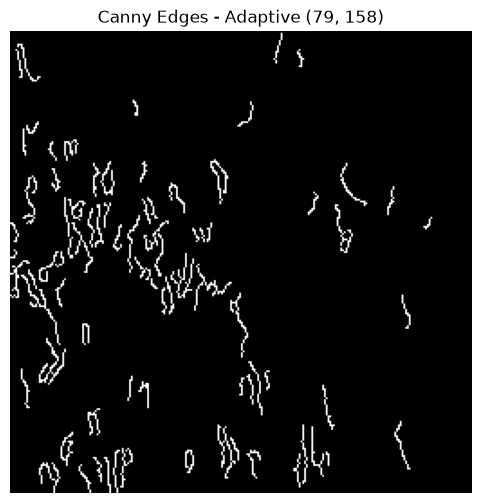

In [60]:
plt.figure(figsize=(6, 6))

plt.imshow(edges, cmap="gray")
plt.title(
    f"Canny Edges - {CANNY_METHOD.capitalize()} "
    f"({lower}, {upper})"
)
plt.axis("off")

plt.show()

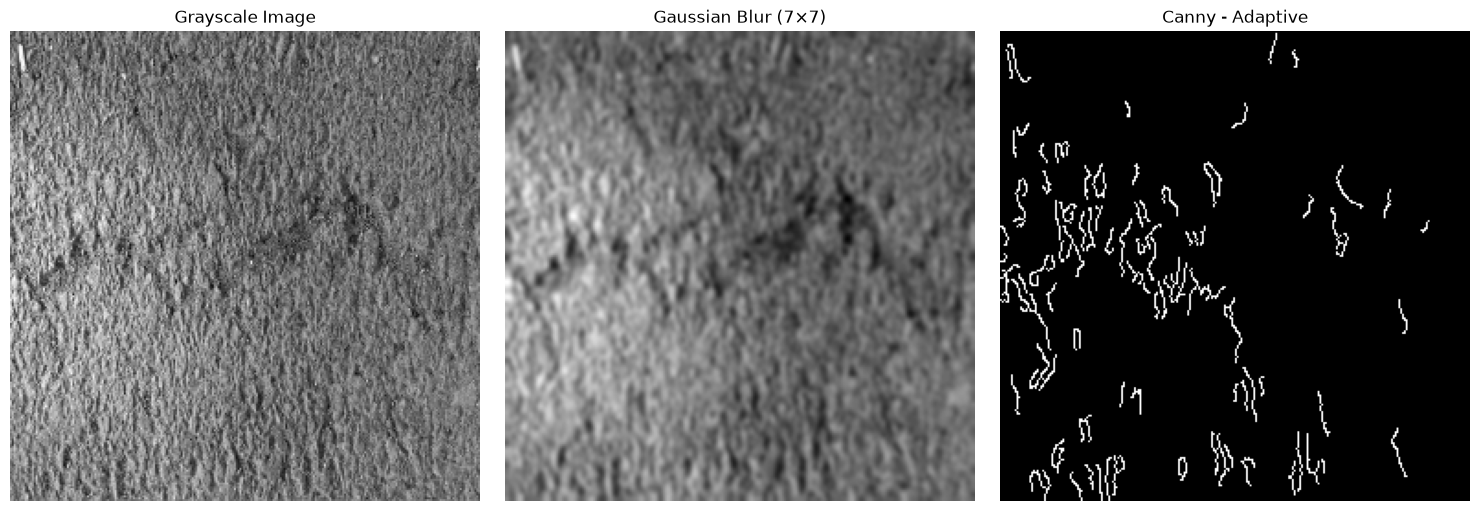

In [61]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blurred_image, cmap="gray")
plt.title("Gaussian Blur (7×7)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title(f"Canny - {CANNY_METHOD.capitalize()}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [62]:
edge_count = np.count_nonzero(edges)
edge_density = edge_count / edges.size

print("Edge count:", edge_count)
print("Edge density:", edge_density)

Edge count: 2272
Edge density: 0.03466796875


In [63]:
sample_features = {
    "mean_brightness": mean_brightness,
    "contrast": contrast,
    "min_intensity": min_intensity,
    "max_intensity": max_intensity,
    "median_intensity": median_intensity,
    "q25": q25,
    "q75": q75,
    "iqr": iqr,
    "dark_pixel_ratio": dark_pixel_ratio,
    "bright_pixel_ratio": bright_pixel_ratio,
    "intensity_range": intensity_range,
    "edge_count": edge_count,
    "edge_density": edge_density
}

sample_features

{'mean_brightness': np.float64(121.95809936523438),
 'contrast': np.float64(33.3530377060264),
 'min_intensity': np.uint8(11),
 'max_intensity': np.uint8(251),
 'median_intensity': np.float64(120.0),
 'q25': np.float64(98.0),
 'q75': np.float64(143.0),
 'iqr': np.float64(45.0),
 'dark_pixel_ratio': np.float64(0.0063934326171875),
 'bright_pixel_ratio': np.float64(0.0142974853515625),
 'intensity_range': np.uint8(240),
 'edge_count': np.int64(2272),
 'edge_density': np.float64(0.03466796875)}

In [65]:
DATASET_PATH = "dataset/448"

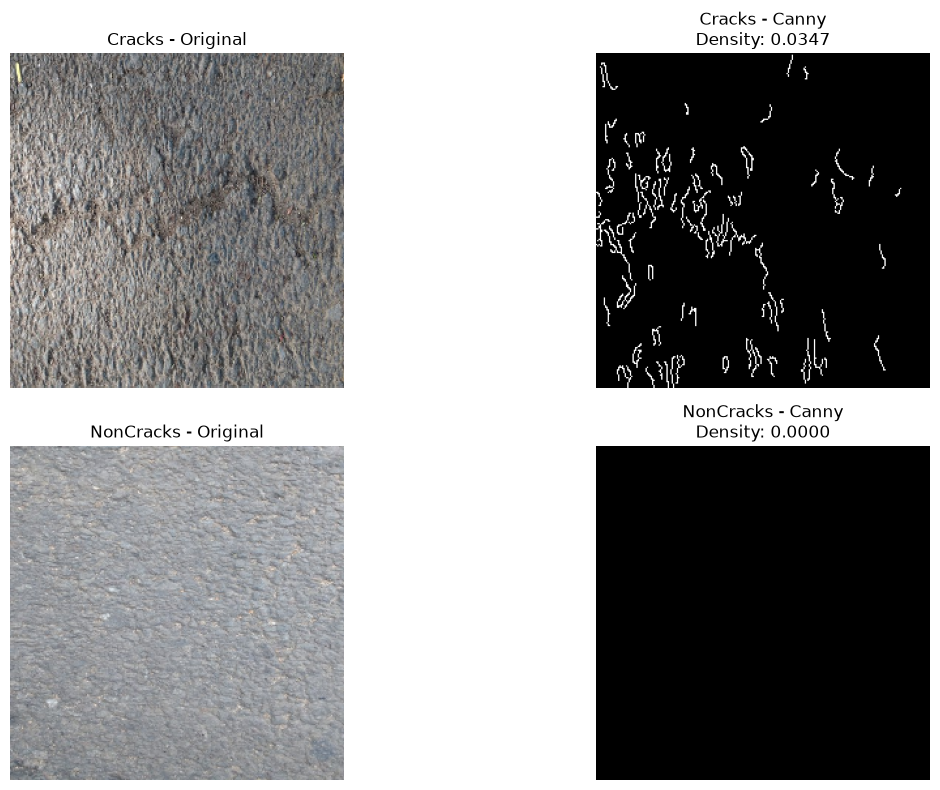

In [66]:
class_folders = [
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
]

plt.figure(figsize=(14, 8))

for i, folder in enumerate(class_folders[:2]):
    folder_path = os.path.join(DATASET_PATH, folder)

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(folder_path, image_files[0])
    TARGET_SIZE = (256,256)
    image = cv2.resize(cv2.imread(image_path), TARGET_SIZE)
    gray  = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)   
    

    
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    if CANNY_METHOD == "normal":
        lower = 100
        upper = 200

    elif CANNY_METHOD == "adaptive":
        median = np.median(blurred)
        sigma = 0.33

        lower = int(max(0, (1.0 - sigma) * median))
        upper = int(min(255, (1.0 + sigma) * median))

    edges = cv2.Canny(blurred, lower, upper)

    edge_count = np.count_nonzero(edges)
    edge_density = edge_count / edges.size

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, 2*i + 1)
    plt.imshow(image_rgb)
    plt.title(f"{folder} - Original")
    plt.axis("off")

    plt.subplot(2, 2, 2*i + 2)
    plt.imshow(edges, cmap="gray")
    plt.title(
        f"{folder} - Canny\n"
        f"Density: {edge_density:.4f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [67]:
comparison_rows = []

folders = [
    f for f in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, f))
]

non_crack_folder = next(f for f in folders if "non" in f.lower())
crack_folder = next(
    f for f in folders
    if "crack" in f.lower() and "non" not in f.lower()
)

selected_folders = [
    ("Crack", crack_folder),
    ("Non-Crack", non_crack_folder)
]

for label, folder in selected_folders:

    folder_path = os.path.join(DATASET_PATH, folder)

    files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(folder_path, files[0])

    image = cv2.imread(image_path)
    image = cv2.resize(image, TARGET_SIZE)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    median_intensity = np.median(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    if CANNY_METHOD == "normal":
        lower = 100
        upper = 200

    elif CANNY_METHOD == "adaptive":
        median = np.median(blurred)
        sigma = 0.33

        lower = int(max(0, (1.0 - sigma) * median))
        upper = int(min(255, (1.0 + sigma) * median))

    edges = cv2.Canny(blurred, lower, upper)

    edge_count = np.count_nonzero(edges)
    edge_density = edge_count / edges.size

    comparison_rows.append({
        "class": label,
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "median_intensity": median_intensity,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "edge_count": edge_count,
        "edge_density": edge_density,
        "canny_lower": lower,
        "canny_upper": upper
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,class,mean_brightness,contrast,median_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_count,edge_density,canny_lower,canny_upper
0,Crack,121.958099,33.353038,120.0,0.006393,0.014297,2272,0.034668,79,158
1,Non-Crack,157.136887,16.379736,157.0,0.000000,0.005539,0,0.000000,105,210


In [68]:
def extract_image_features(image_path, label):

    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.resize(image, TARGET_SIZE)

    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    contrast = np.std(gray)

    min_intensity = np.min(gray)
    max_intensity = np.max(gray)
    median_intensity = np.median(gray)

    q25 = np.percentile(gray, 25)
    q75 = np.percentile(gray, 75)
    iqr = q75 - q25

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    intensity_range = max_intensity - min_intensity

    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    if CANNY_METHOD == "normal":
        lower = 100
        upper = 200

    elif CANNY_METHOD == "adaptive":
        median = np.median(blurred)
        sigma = 0.33

        lower = int(max(0, (1.0 - sigma) * median))
        upper = int(min(255, (1.0 + sigma) * median))

    edges = cv2.Canny(blurred, lower, upper)

    edge_count = np.count_nonzero(edges)
    edge_density = edge_count / edges.size

    return {
        "image_name": os.path.basename(image_path),
        "label": label,

        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "q25": q25,
        "q75": q75,
        "iqr": iqr,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "intensity_range": intensity_range,

        "edge_count": edge_count,
        "edge_density": edge_density
    }

In [69]:
feature_rows = []

for label, folder in selected_folders:

    folder_path = os.path.join(DATASET_PATH, folder)

    files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for file in files:

        image_path = os.path.join(folder_path, file)

        features = extract_image_features(
            image_path,
            label
        )

        if features is not None:
            feature_rows.append(features)

image_features_df = pd.DataFrame(feature_rows)

print("Total images processed:", len(image_features_df))
print("Feature table shape:", image_features_df.shape)

image_features_df.head()

Total images processed: 400
Feature table shape: (400, 15)


,image_name,label,mean_brightness,contrast,min_intensity,max_intensity,median_intensity,q25,q75,iqr,dark_pixel_ratio,bright_pixel_ratio,intensity_range,edge_count,edge_density
0,IMG_20180513_164959951_HDR resized_448.jpg,Crack,121.958099,33.353038,11,251,120.0,98.0,143.0,45.0,0.006393,0.014297,240,2272,0.034668
1,IMG_20180513_165129852_HDR resized_448.jpg,Crack,131.714722,25.580155,2,245,133.0,117.0,148.0,31.0,0.003555,0.005768,243,487,0.007431
2,IMG_20180513_165150613_HDR resized_448.jpg,Crack,121.036026,31.582693,1,248,120.0,103.0,138.0,35.0,0.016434,0.010468,247,2526,0.038544
3,IMG_20180513_165345878_HDR resized_448.jpg,Crack,130.010712,27.813358,12,253,131.0,112.0,149.0,37.0,0.003372,0.006348,241,999,0.015244
4,IMG_20180513_165349788_HDR resized_448.jpg,Crack,130.882675,28.393991,6,253,132.0,113.0,149.0,36.0,0.004120,0.008453,247,1248,0.019043


In [70]:
feature_df.to_csv("image_features.csv", index=False)

print("image_features.csv saved")

image_features.csv saved


In [72]:
image_features_df["label"].value_counts()

numeric_features = image_features_df.select_dtypes(include=np.number).columns

class_feature_means = (
    image_features_df
    .groupby("label")[numeric_features]
    .mean()
    .round(4)
)

class_feature_means.T

label,Crack,Non-Crack
mean_brightness,144.1359,157.4001
contrast,31.5844,24.7643
min_intensity,25.0400,59.0700
max_intensity,252.2700,251.6950
median_intensity,144.3350,157.1550
q25,123.7150,140.7600
q75,164.9850,173.4850
iqr,41.2700,32.7250
dark_pixel_ratio,0.0095,0.0007
bright_pixel_ratio,0.0756,0.0498


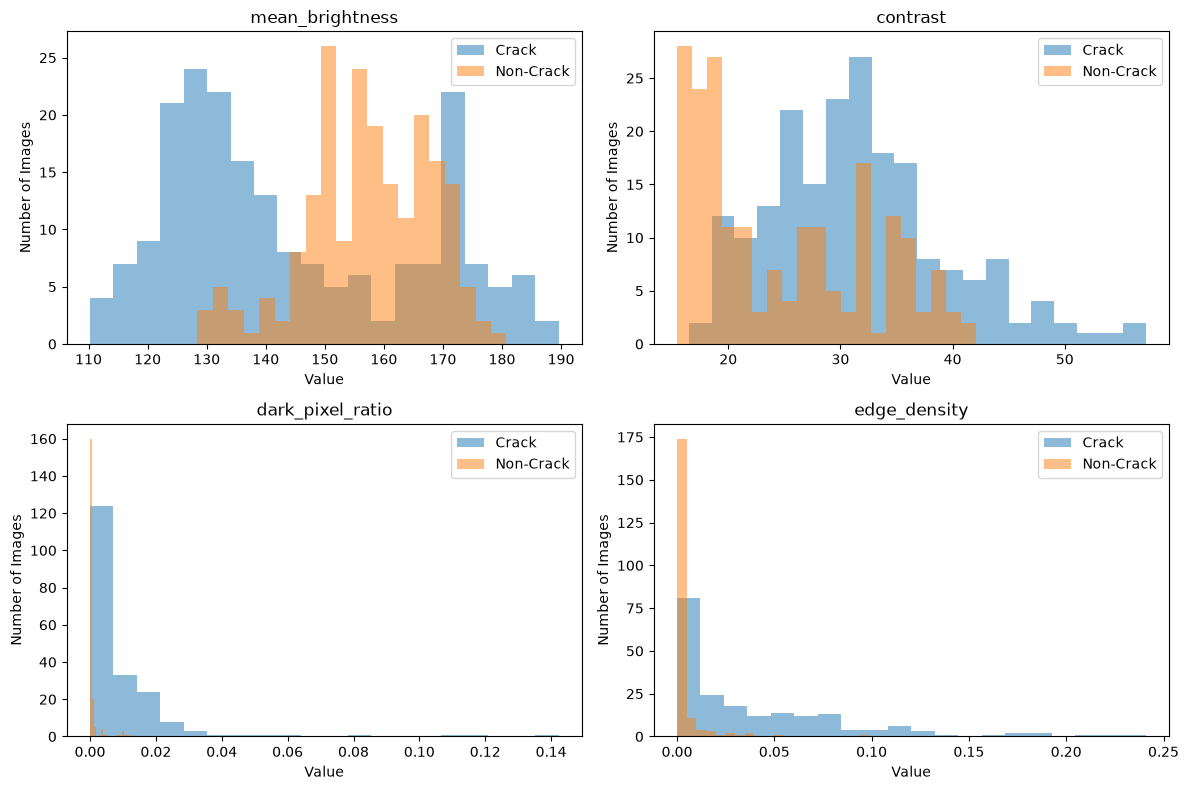

In [73]:
features_to_plot = [
    "mean_brightness",
    "contrast",
    "dark_pixel_ratio",
    "edge_density"
]

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features_to_plot, 1):

    plt.subplot(2, 2, i)

    for label in image_features_df["label"].unique():

        values = image_features_df[
            image_features_df["label"] == label
        ][feature]

        plt.hist(
            values,
            bins=20,
            alpha=0.5,
            label=label
        )

    plt.title(feature)
    plt.xlabel("Value")
    plt.ylabel("Number of Images")
    plt.legend()

plt.tight_layout()
plt.show()

In [74]:
feature_columns = [
    "mean_brightness",
    "contrast",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "q25",
    "q75",
    "iqr",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "intensity_range",
    "edge_count",
    "edge_density"
]

X = image_features_df[feature_columns]

clean_labels = (
    image_features_df["label"]
    .astype(str)
    .str.strip()
)

label_mapping = {
    "Crack": 1,
    "Non-Crack": 0
}

y = clean_labels.map(label_mapping)

print("Original labels:", image_features_df["label"].unique())
print("Mapped labels:")
print(y.value_counts(dropna=False))

if y.isna().any():
    raise ValueError("Some labels could not be mapped.")

y = y.astype(int)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Original labels: <ArrowStringArray>
['Crack', 'Non-Crack']
Length: 2, dtype: str
Mapped labels:
label
1    200
0    200
Name: count, dtype: int64

X shape: (400, 13)
y shape: (400,)


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (320, 13)
Testing set: (80, 13)


In [76]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
label
1    160
0    160
Name: count, dtype: int64

Testing class distribution:
label
0    40
1    40
Name: count, dtype: int64


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (320, 13)
Testing shape: (80, 13)


In [78]:
from sklearn.linear_model import LogisticRegression
import time

lr_model = LogisticRegression(
    max_iter=1500,
    random_state=42
)

start = time.perf_counter()

lr_model.fit(X_train_scaled, y_train)

lr_train_time = time.perf_counter() - start

print("Training time:", lr_train_time)

Training time: 0.12926740001421422


In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

start = time.perf_counter()

lr_predictions = lr_model.predict(X_test_scaled)

lr_predict_time = time.perf_counter() - start

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-score :", lr_f1)

print("\nTraining time  :", lr_train_time)
print("Prediction time:", lr_predict_time)

Accuracy : 0.9375
Precision: 0.9487179487179487
Recall   : 0.925
F1-score : 0.9367088607594937

Training time  : 0.12926740001421422
Prediction time: 0.001583400066010654


In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start

print("Training time:", rf_train_time)

Training time: 2.412385940551758


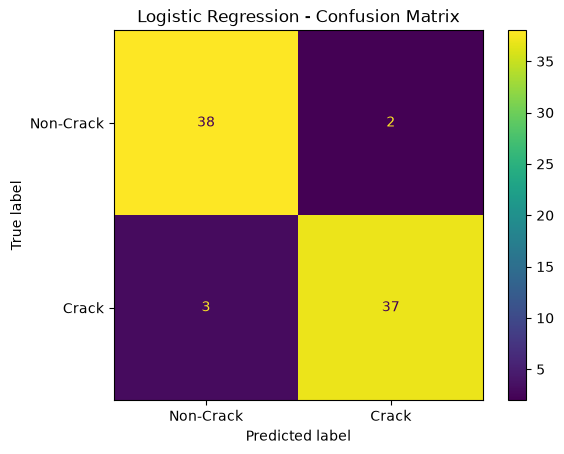

In [82]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    display_labels=["Non-Crack", "Crack"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [83]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=7,
    random_state=42
)

DecisionTreeClassifier()

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [84]:

start = time.perf_counter()
dt_model.fit(X_train, y_train)
dt_train_time = time.perf_counter() - start

start = time.perf_counter()
dt_predictions = dt_model.predict(X_test)
dt_predict_time = time.perf_counter() - start

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)

print("\nTraining time  :", dt_train_time)
print("Prediction time:", dt_predict_time)

Accuracy : 0.925
Precision: 0.9473684210526315
Recall   : 0.9
F1-score : 0.9230769230769231

Training time  : 0.01610530004836619
Prediction time: 0.026200300082564354


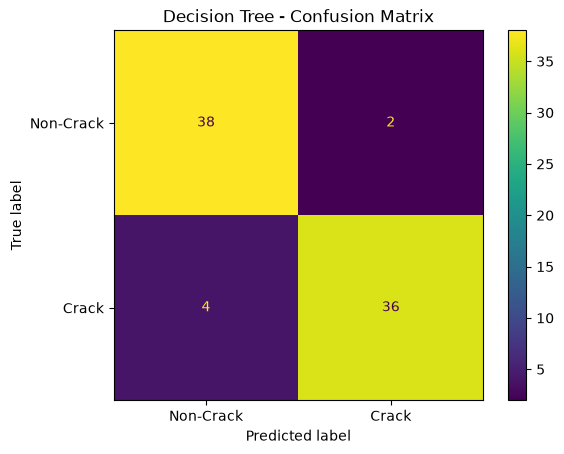

In [85]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_predictions,
    display_labels=["Non-Crack", "Crack"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [86]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

start = time.perf_counter()
rf_model.fit(X_train, y_train)
rf_train_time = time.perf_counter() - start

start = time.perf_counter()
rf_predictions = rf_model.predict(X_test)
rf_predict_time = time.perf_counter() - start

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-score :", rf_f1)

print("\nTraining time  :", rf_train_time)
print("Prediction time:", rf_predict_time)

Accuracy : 0.9375
Precision: 0.9487179487179487
Recall   : 0.925
F1-score : 0.9367088607594937

Training time  : 2.328663899912499
Prediction time: 0.17589189996942878


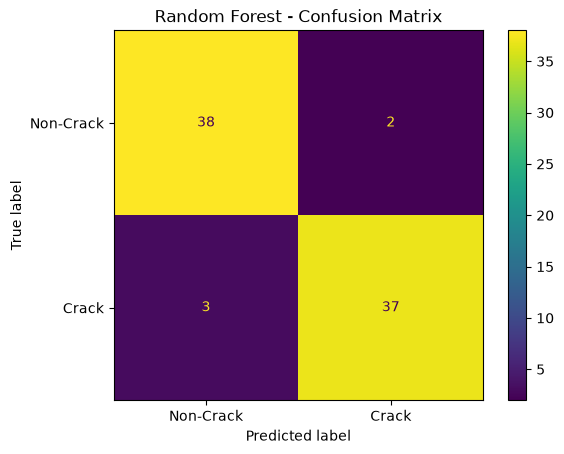

In [87]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["Non-Crack", "Crack"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [88]:
image_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ],
    "Training Time": [
        lr_train_time,
        dt_train_time,
        rf_train_time
    ],
    "Prediction Time": [
        lr_predict_time,
        dt_predict_time,
        rf_predict_time
    ]
})

image_model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
0,Logistic Regression,0.9375,0.9487,0.925,0.9367,0.1293,0.0016
1,Decision Tree,0.9250,0.9474,0.900,0.9231,0.0161,0.0262
2,Random Forest,0.9375,0.9487,0.925,0.9367,2.3287,0.1759


### Part B 


In [89]:
TEXT_DATA_PATH = "emails.csv"

email_df = pd.read_csv(TEXT_DATA_PATH)

print("Dataset shape:", email_df.shape)

email_df.head()

Dataset shape: (5172, 3002)


,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [90]:
print("Columns:")
print(email_df.columns.tolist())

print("\nMissing values:")
print(email_df.isnull().sum())

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here', 'like', 'b', 'flow', 'net', 

In [91]:
print(email_df["Prediction"].value_counts())

print("\nPercentages:")
print(
    email_df["Prediction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Prediction
0    3672
1    1500
Name: count, dtype: int64

Percentages:
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64


In [92]:
target_counts = email_df["Prediction"].value_counts().sort_index()

print("Prediction distribution:")
print(target_counts)

print("\nPrediction percentage:")
print(
    email_df["Prediction"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Prediction distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64

Prediction percentage:
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64


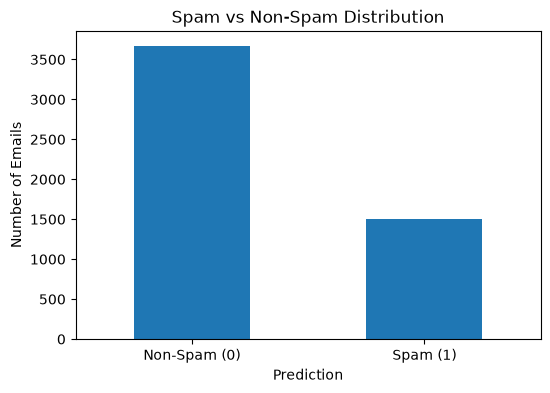

In [93]:
plt.figure(figsize=(6, 4))

target_counts.plot(kind="bar")

plt.title("Spam vs Non-Spam Distribution")
plt.xlabel("Prediction")
plt.ylabel("Number of Emails")
plt.xticks(
    [0, 1],
    ["Non-Spam (0)", "Spam (1)"],
    rotation=0
)

plt.show()

In [94]:
print("Unique labels:", sorted(email_df["Prediction"].unique()))

print("\nNumber of columns:", len(email_df.columns))

print("\nFirst 20 columns:")
print(email_df.columns[:20].tolist())

print("\nLast 10 columns:")
print(email_df.columns[-10:].tolist())

Unique labels: [np.int64(0), np.int64(1)]

Number of columns: 3002

First 20 columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have']

Last 10 columns:
['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military', 'allowing', 'ff', 'dry', 'Prediction']


In [95]:
X_text = email_df.drop(
    columns=["Prediction", "Email No.", "Total_Word_Count"],
    errors="ignore"
)

y_text = email_df["Prediction"]

print("X shape:", X_text.shape)
print("y shape:", y_text.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [96]:
print("Minimum feature value:", X_text.min().min())
print("Maximum feature value:", X_text.max().max())

zero_ratio = (X_text == 0).sum().sum() / X_text.size

print("Zero-value ratio:", round(zero_ratio, 4))

Minimum feature value: 0
Maximum feature value: 2327
Zero-value ratio: 0.9437


In [97]:
X_text = email_df.drop(
    columns=["Prediction", "Email No.", "Total_Word_Count"],
    errors="ignore"
)

y_text = email_df["Prediction"]

print("X shape:", X_text.shape)
print("y shape:", y_text.shape)

X shape: (5172, 3000)
y shape: (5172,)


In [113]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.20,
    random_state=42,
    stratify=y_text
)

print("Training set:", X_train_text.shape)
print("Testing set:", X_test_text.shape)

Training set: (4137, 3000)
Testing set: (1035, 3000)


In [98]:
print("Minimum feature value:", X_text.min().min())
print("Maximum feature value:", X_text.max().max())

zero_ratio = (X_text == 0).sum().sum() / X_text.size

print("Zero-value ratio:", round(zero_ratio, 4))

Minimum feature value: 0
Maximum feature value: 2327
Zero-value ratio: 0.9437


In [99]:
print("Minimum feature value:", X_text.min().min())
print("Maximum feature value:", X_text.max().max())

zero_ratio = (X_text == 0).sum().sum() / X_text.size

print("Zero-value ratio:", round(zero_ratio, 4))

Minimum feature value: 0
Maximum feature value: 2327
Zero-value ratio: 0.9437


In [100]:
print("Training distribution:")
print(y_train_text.value_counts())

print("\nTesting distribution:")
print(y_test_text.value_counts())

Training distribution:
Prediction
0    2937
1    1200
Name: count, dtype: int64

Testing distribution:
Prediction
0    735
1    300
Name: count, dtype: int64


In [101]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

start = time.perf_counter()

nb_model.fit(X_train_text, y_train_text)

nb_train_time = time.perf_counter() - start

start = time.perf_counter()

nb_predictions = nb_model.predict(X_test_text)

nb_predict_time = time.perf_counter() - start

print("Training time:", nb_train_time)
print("Prediction time:", nb_predict_time)

Training time: 2.014109899988398
Prediction time: 1.1714657000266016


In [102]:
nb_accuracy = accuracy_score(y_test_text, nb_predictions)
nb_precision = precision_score(y_test_text, nb_predictions)
nb_recall = recall_score(y_test_text, nb_predictions)
nb_f1 = f1_score(y_test_text, nb_predictions)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1-score :", nb_f1)

print("\nTraining time  :", nb_train_time)
print("Prediction time:", nb_predict_time)

Accuracy : 0.9420289855072463
Precision: 0.8680981595092024
Recall   : 0.9433333333333334
F1-score : 0.9041533546325878

Training time  : 2.014109899988398
Prediction time: 1.1714657000266016


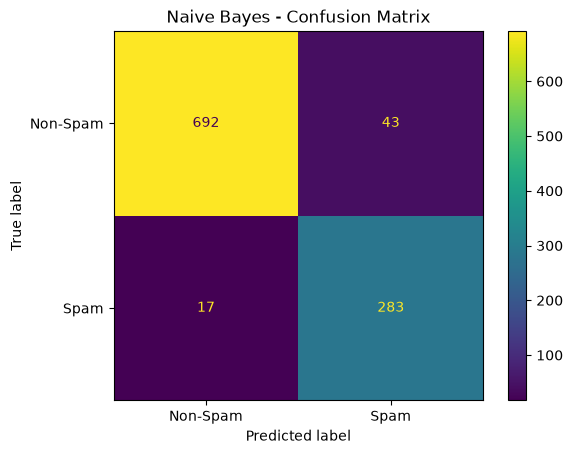

In [103]:
ConfusionMatrixDisplay.from_predictions(
    y_test_text,
    nb_predictions,
    display_labels=["Non-Spam", "Spam"]
)

plt.title("Naive Bayes - Confusion Matrix")
plt.show()

In [104]:
text_lr_model = LogisticRegression(
    max_iter=1500,
    random_state=42
)

start = time.perf_counter()
text_lr_model.fit(X_train_text, y_train_text)
text_lr_train_time = time.perf_counter() - start

start = time.perf_counter()
text_lr_predictions = text_lr_model.predict(X_test_text)
text_lr_predict_time = time.perf_counter() - start

text_lr_accuracy = accuracy_score(y_test_text, text_lr_predictions)
text_lr_precision = precision_score(y_test_text, text_lr_predictions)
text_lr_recall = recall_score(y_test_text, text_lr_predictions)
text_lr_f1 = f1_score(y_test_text, text_lr_predictions)

print("Accuracy :", text_lr_accuracy)
print("Precision:", text_lr_precision)
print("Recall   :", text_lr_recall)
print("F1-score :", text_lr_f1)

print("\nTraining time  :", text_lr_train_time)
print("Prediction time:", text_lr_predict_time)

Accuracy : 0.9826086956521739
Precision: 0.9577922077922078
Recall   : 0.9833333333333333
F1-score : 0.9703947368421053

Training time  : 35.01343359996099
Prediction time: 0.34026470000389963


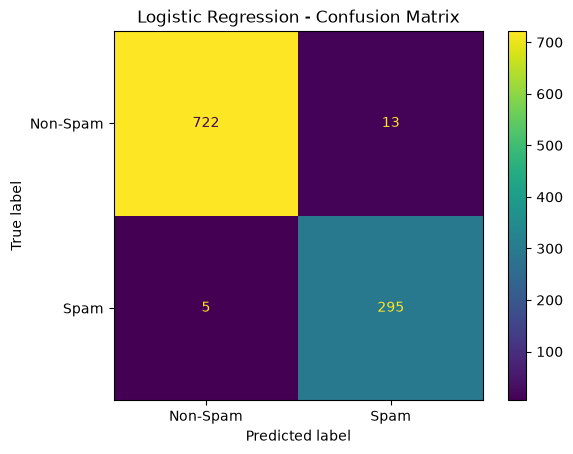

In [105]:
ConfusionMatrixDisplay.from_predictions(
    y_test_text,
    text_lr_predictions,
    display_labels=["Non-Spam", "Spam"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [106]:
text_model_results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        text_lr_accuracy
    ],
    "Precision": [
        nb_precision,
        text_lr_precision
    ],
    "Recall": [
        nb_recall,
        text_lr_recall
    ],
    "F1 Score": [
        nb_f1,
        text_lr_f1
    ],
    "Training Time": [
        nb_train_time,
        text_lr_train_time
    ],
    "Prediction Time": [
        nb_predict_time,
        text_lr_predict_time
    ]
})

text_model_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
0,Multinomial Naive Bayes,0.9420,0.8681,0.9433,0.9042,2.0141,1.1715
1,Logistic Regression,0.9826,0.9578,0.9833,0.9704,35.0134,0.3403


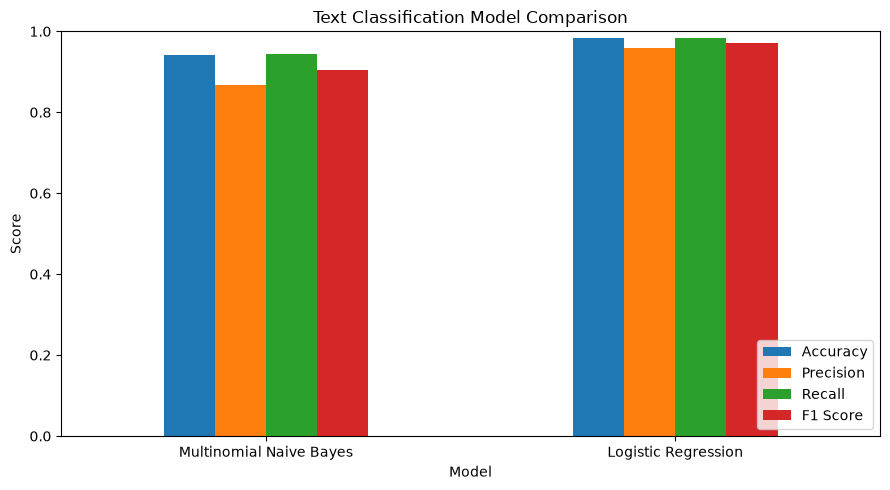

In [107]:
text_model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Text Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Part C


In [108]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(
    score_func=chi2,
    k=1000
)

X_train_reduced = selector.fit_transform(
    X_train_text,
    y_train_text
)

X_test_reduced = selector.transform(
    X_test_text
)

print("Original features:", X_train_text.shape[1])
print("Reduced features:", X_train_reduced.shape[1])

Original features: 3000
Reduced features: 1000


In [109]:


nb_reduced = MultinomialNB()

start = time.perf_counter()
nb_reduced.fit(X_train_reduced, y_train_text)
nb_reduced_train_time = time.perf_counter() - start

start = time.perf_counter()
nb_reduced_predictions = nb_reduced.predict(X_test_reduced)
nb_reduced_predict_time = time.perf_counter() - start

nb_reduced_accuracy = accuracy_score(
    y_test_text,
    nb_reduced_predictions
)

nb_reduced_precision = precision_score(
    y_test_text,
    nb_reduced_predictions
)

nb_reduced_recall = recall_score(
    y_test_text,
    nb_reduced_predictions
)

nb_reduced_f1 = f1_score(
    y_test_text,
    nb_reduced_predictions
)

print("Accuracy :", nb_reduced_accuracy)
print("Precision:", nb_reduced_precision)
print("Recall   :", nb_reduced_recall)
print("F1-score :", nb_reduced_f1)

print("\nTraining time  :", nb_reduced_train_time)
print("Prediction time:", nb_reduced_predict_time)

Accuracy : 0.936231884057971
Precision: 0.8588957055214724
Recall   : 0.9333333333333333
F1-score : 0.8945686900958466

Training time  : 0.05823050008621067
Prediction time: 0.025775999994948506


In [110]:
representation_results = pd.DataFrame({
    "Representation": [
        "Original",
        "Reduced - 1000 Features"
    ],

    "Number of Features": [
        X_train_text.shape[1],
        X_train_reduced.shape[1]
    ],

    "Accuracy": [
        nb_accuracy,
        nb_reduced_accuracy
    ],

    "Precision": [
        nb_precision,
        nb_reduced_precision
    ],

    "Recall": [
        nb_recall,
        nb_reduced_recall
    ],

    "F1 Score": [
        nb_f1,
        nb_reduced_f1
    ],

    "Training Time": [
        nb_train_time,
        nb_reduced_train_time
    ],

    "Prediction Time": [
        nb_predict_time,
        nb_reduced_predict_time
    ]
})

representation_results.round(4)

,Representation,Number of Features,Accuracy,Precision,Recall,F1 Score,Training Time,Prediction Time
0,Original,3000,0.9420,0.8681,0.9433,0.9042,2.0141,1.1715
1,Reduced - 1000 Features,1000,0.9362,0.8589,0.9333,0.8946,0.0582,0.0258


In [111]:
text_lr_reduced = LogisticRegression(
    max_iter=1500,
    random_state=42
)

start = time.perf_counter()
text_lr_reduced.fit(X_train_reduced, y_train_text)
text_lr_reduced_train_time = time.perf_counter() - start

start = time.perf_counter()
text_lr_reduced_predictions = text_lr_reduced.predict(X_test_reduced)
text_lr_reduced_predict_time = time.perf_counter() - start

text_lr_reduced_accuracy = accuracy_score(
    y_test_text,
    text_lr_reduced_predictions
)

text_lr_reduced_precision = precision_score(
    y_test_text,
    text_lr_reduced_predictions
)

text_lr_reduced_recall = recall_score(
    y_test_text,
    text_lr_reduced_predictions
)

text_lr_reduced_f1 = f1_score(
    y_test_text,
    text_lr_reduced_predictions
)

print("Accuracy :", text_lr_reduced_accuracy)
print("Precision:", text_lr_reduced_precision)
print("Recall   :", text_lr_reduced_recall)
print("F1-score :", text_lr_reduced_f1)

print("\nTraining time  :", text_lr_reduced_train_time)
print("Prediction time:", text_lr_reduced_predict_time)

Accuracy : 0.9729468599033816
Precision: 0.9473684210526315
Recall   : 0.96
F1-score : 0.9536423841059603

Training time  : 18.128429500036873
Prediction time: 0.04498620005324483


In [112]:
representation_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Naive Bayes",
        "Logistic Regression",
        "Logistic Regression"
    ],

    "Representation": [
        "Original",
        "Reduced",
        "Original",
        "Reduced"
    ],

    "Features": [
        X_train_text.shape[1],
        X_train_reduced.shape[1],
        X_train_text.shape[1],
        X_train_reduced.shape[1]
    ],

    "Accuracy": [
        nb_accuracy,
        nb_reduced_accuracy,
        text_lr_accuracy,
        text_lr_reduced_accuracy
    ],

    "F1 Score": [
        nb_f1,
        nb_reduced_f1,
        text_lr_f1,
        text_lr_reduced_f1
    ],

    "Training Time": [
        nb_train_time,
        nb_reduced_train_time,
        text_lr_train_time,
        text_lr_reduced_train_time
    ],

    "Prediction Time": [
        nb_predict_time,
        nb_reduced_predict_time,
        text_lr_predict_time,
        text_lr_reduced_predict_time
    ]
})

representation_results.round(4)

,Model,Representation,Features,Accuracy,F1 Score,Training Time,Prediction Time
0,Naive Bayes,Original,3000,0.9420,0.9042,2.0141,1.1715
1,Naive Bayes,Reduced,1000,0.9362,0.8946,0.0582,0.0258
2,Logistic Regression,Original,3000,0.9826,0.9704,35.0134,0.3403
3,Logistic Regression,Reduced,1000,0.9729,0.9536,18.1284,0.0450
